# Online Retail - RFM Preprocessing

Follows Chen et al. (2012), *Data mining for the online retail industry*, pages 4-5.

**Key rule in this notebook:** `df` always keeps every clean transaction, including
cancellations. Filtered views such as `purchases` are separate variables. Nothing is
overwritten in a way that loses the refund rows - that is what caused the phantom
revenue problem.

## 1. Load

In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel("Online Retail.xlsx")
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


## 2. Duplicates

Rows identical across all 8 columns - same invoice, product, quantity and timestamp.
The schema is one line per (invoice, product), so these are export artefacts.

In [3]:
df.duplicated().sum()

np.int64(5268)

In [4]:
df = df.drop_duplicates()
df.shape

(536641, 8)

## 3. Missing values

`CustomerID` is the identifier we aggregate by. `groupby` silently discards NaN keys,
so drop them explicitly rather than letting it happen invisibly.

In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [6]:
df = df.dropna(subset=["CustomerID"])
df["CustomerID"] = df["CustomerID"].astype(int)
df.shape

(401604, 8)

## 4. United Kingdom only

Paper step 4. The public file has no PostCode, so `CustomerID` is our buyer identifier.

In [7]:
df["Country"].value_counts().head()

Country
United Kingdom    356728
Germany             9480
France              8475
EIRE                7475
Spain               2528
Name: count, dtype: int64

In [8]:
df = df[df["Country"] == "United Kingdom"].copy()
df.shape

(356728, 8)

## 5. Zero-price rows

Giveaways and admin adjustments. They contribute nothing to Monetary.

In [9]:
(df["UnitPrice"] <= 0).sum()

np.int64(24)

In [10]:
df = df[df["UnitPrice"] > 0]
df.shape

(356704, 8)

## 6. Split InvoiceDate into Date and Time

Paper step 3.

In [11]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Date"] = df["InvoiceDate"].dt.normalize()
df["Time"] = df["InvoiceDate"].dt.time
df = df.drop(columns="InvoiceDate")
df.head()

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Time
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850,United Kingdom,2010-12-01,08:26:00
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850,United Kingdom,2010-12-01,08:26:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850,United Kingdom,2010-12-01,08:26:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850,United Kingdom,2010-12-01,08:26:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850,United Kingdom,2010-12-01,08:26:00


## 7. Amount

Paper step 2. Negative for cancellations, which is exactly what we want - it lets
refunds cancel out purchases when we sum.

In [12]:
df["Amount"] = df["Quantity"] * df["UnitPrice"]
df[["Quantity", "UnitPrice", "Amount"]].describe()

,Quantity,UnitPrice,Amount
count,356704.000000,356704.000000,356704.000000
mean,11.163704,3.268475,18.915280
std,264.175357,71.164719,455.172315
min,-80995.000000,0.001000,-168469.600000
25%,2.000000,1.250000,3.900000
50%,4.000000,1.950000,10.200000
75%,12.000000,3.750000,17.700000
max,80995.000000,38970.000000,168469.600000


## 8. Cancellations

Invoice numbers starting with `C` are cancellations. **We do not delete them.**

Deleting them removes the refund but keeps the original order, which invents revenue
that never existed. Customer 12346 ordered 74,215 jars and cancelled all of them
16 minutes later - delete the `C` row and they look like a GBP 77,183 customer instead
of a GBP 0 one. That affects 1,382 customers and GBP 528,823 in total.

Instead we keep `df` whole and make a separate `purchases` view.

In [13]:
is_cancel = df["InvoiceNo"].astype(str).str.startswith("C")
print(f"cancellation rows: {is_cancel.sum()}")

purchases = df[~is_cancel]
print(f"purchase rows:     {len(purchases)}")

df[df["CustomerID"] == 12346][["InvoiceNo", "Description", "Quantity", "Amount"]]

cancellation rows: 7501
purchase rows:     349203


,InvoiceNo,Description,Quantity,Amount
61619,541431,MEDIUM CERAMIC TOP STORAGE JAR,74215,77183.6
61624,C541433,MEDIUM CERAMIC TOP STORAGE JAR,-74215,-77183.6


## 9. Build the target dataset

Paper step 5, with the columns from Figure 1.

The two sources are deliberate:

- **Recency, Frequency, First_Purchase** come from `purchases` - a refund is not a shop
  visit, so it should not count as recent activity or as an order.
- **Monetary** comes from `df` - the full picture including refunds, so it measures the
  money the business actually kept.

In [14]:
snapshot = df["Date"].max() + pd.Timedelta(days=1)
print("snapshot date:", snapshot.date())

target = purchases.groupby("CustomerID").agg(
    First_Purchase=("Date", lambda x: (snapshot - x.min()).days),
    Recency=("Date", lambda x: (snapshot - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Min=("Amount", "min"),
    Max=("Amount", "max"),
    Mean=("Amount", "mean"),
)

target["Monetary"] = df.groupby("CustomerID")["Amount"].sum()

target = target.round(2)
target = target[target["Monetary"] > 0].reset_index()
target = target[["CustomerID", "First_Purchase", "Recency",
                 "Frequency", "Monetary", "Min", "Max", "Mean"]]

print(target.shape)
target.head()

snapshot date: 2011-12-10
(3902, 8)


,CustomerID,First_Purchase,Recency,Frequency,Monetary,Min,Max,Mean
0,12747,370,3,11,4196.01,10.20,243.00,40.74
1,12748,374,1,209,28405.56,0.06,850.50,7.49
2,12749,214,4,5,3868.20,6.64,114.75,20.56
3,12820,327,4,4,942.34,6.96,37.80,15.97
4,12821,215,215,1,92.72,10.20,19.92,15.45


### Check the phantom customers are gone

12346 (net GBP 0) and 16446 (net GBP 2.90) were pure cancellations. Both should now be
absent, or corrected to their true value.

In [15]:
target[target["CustomerID"].isin([12346, 16446])]

,CustomerID,First_Purchase,Recency,Frequency,Monetary,Min,Max,Mean
2589,16446,206,1,2,2.9,1.25,168469.6,56157.5


## 10. Outliers

Detected with IQR rather than Z-score. Z-score uses the mean and standard deviation,
both inflated by the outliers themselves - on this data it flags 69 customers against
IQR's 555, and flags **zero** on Recency because the variable is bounded at 374 days.

In [16]:
target[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,3902.000000,3902.000000,3902.000000
mean,92.379549,4.260636,1732.193708
std,99.312336,7.212701,6585.055282
min,1.000000,1.000000,2.900000
25%,18.000000,1.000000,290.865000
50%,51.000000,2.000000,633.685000
75%,142.000000,5.000000,1533.925000
max,374.000000,209.000000,256438.490000


In [17]:
cols = ["Recency", "Frequency", "Monetary"]

Q1 = target[cols].quantile(0.25)
Q3 = target[cols].quantile(0.75)
IQR = Q3 - Q1

((target[cols] < Q1 - 1.5 * IQR) | (target[cols] > Q3 + 1.5 * IQR)).sum()

Recency      133
Frequency    261
Monetary     378
dtype: int64

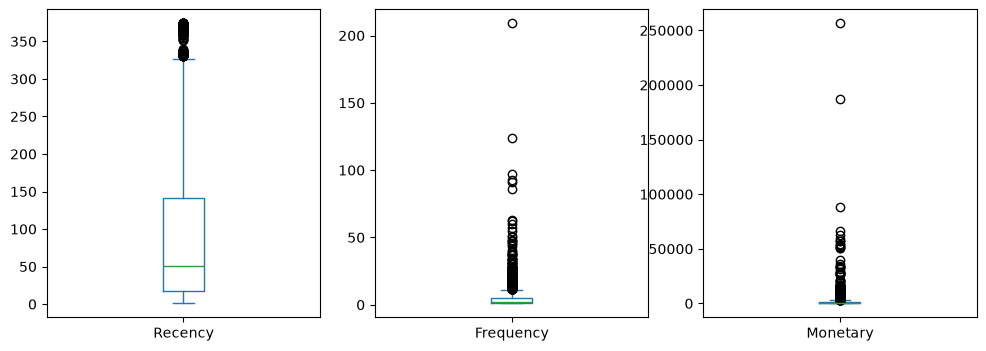

In [18]:
target[cols].plot(kind="box", subplots=True, layout=(1, 3), figsize=(12, 4));

**Treatment: keep them, log-transform them.**

The extremes are wholesale buyers - they order about 3.5x the units per line at similar
prices. That is a real customer segment, and the point of the segmentation is to find
it. Deleting 14% of customers would remove the most valuable ones.

In [19]:
target[cols].skew()

Recency       1.249797
Frequency    10.735499
Monetary     23.230069
dtype: float64

## 11. Log transform

In [20]:
target_log = np.log1p(target[cols])
target_log.skew()

Recency     -0.322560
Frequency    1.177505
Monetary     0.349574
dtype: float64

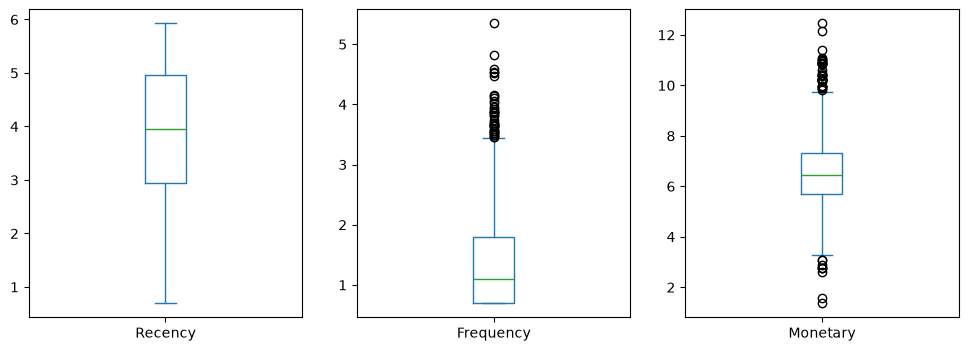

In [21]:
target_log.plot(kind="box", subplots=True, layout=(1, 3), figsize=(12, 4));

## 12. Scale

Paper page 5: *"these variables should be normalized before the clustering analysis."*
Monetary runs to five figures while Frequency is single digits - unscaled, Euclidean
distance is decided by Monetary alone.

`X` is what K-Means sees. `target` keeps real pounds and days for interpreting clusters.

In [22]:
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(target_log)
print(X.shape)
X[:5]

(3902, 3)


array([[-1.88620638,  1.66419106,  1.47982234],
       [-2.41686506,  5.85771019,  3.03394798],
       [-1.71537244,  0.64863482,  1.41372806],
       [-1.71537244,  0.38150859,  0.26667163],
       [ 1.16767464, -0.96098373, -1.60999685]])

## 13. Save

In [24]:
target.to_excel("target_dataset_v2.xlsx", index=False)
target.to_csv("target_dataset_v2.csv", index=False)

---

## Next: clustering

Elbow method to choose `k`, then fit and profile the clusters against the
unscaled `target` table.

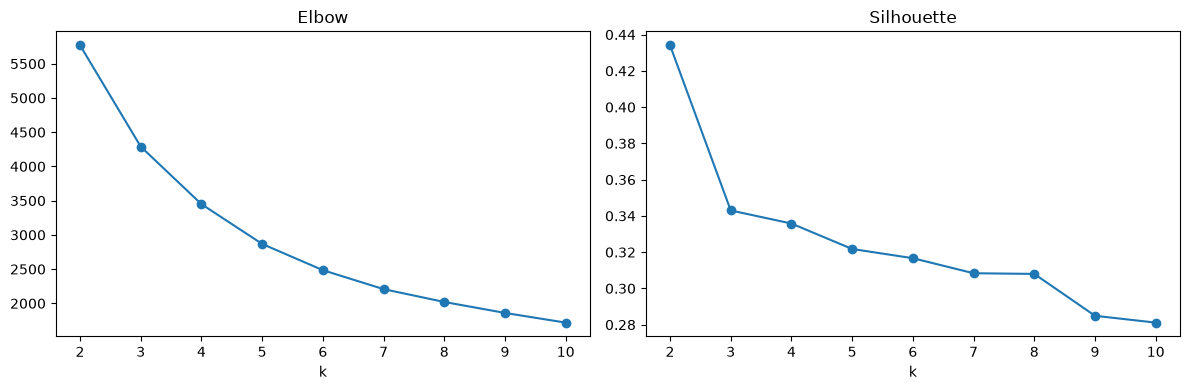

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia, sil = [], []
ks = range(2, 11)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ks, inertia, marker="o"); ax[0].set_title("Elbow"); ax[0].set_xlabel("k")
ax[1].plot(ks, sil, marker="o"); ax[1].set_title("Silhouette"); ax[1].set_xlabel("k")
plt.tight_layout();


# Evaluation 

In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score)

# fit first — this creates the Cluster column
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
target["Cluster"] = kmeans.fit_predict(X)

labels = target["Cluster"]

print("silhouette        :", round(silhouette_score(X, labels), 3))
print("davies-bouldin    :", round(davies_bouldin_score(X, labels), 3))
print("calinski-harabasz :", round(calinski_harabasz_score(X, labels), 1))

print("\nper-cluster:")
s = silhouette_samples(X, labels)
for c in sorted(labels.unique()):
    m = labels == c
    print(f"  cluster {c}: n={m.sum():4d}  silhouette={s[m].mean():.3f}  misfit={int((s[m] < 0).sum())}")
print(f"  total misfits: {int((s < 0).sum())} ({(s < 0).mean():.1%})")

print("\nstability:")
aris = [adjusted_rand_score(labels, KMeans(n_clusters=5, random_state=r, n_init=10).fit_predict(X))
        for r in range(10)]
print("  ARI over 10 seeds:", round(np.mean(aris), 3), "| min:", round(min(aris), 3))


silhouette        : 0.322
davies-bouldin    : 0.987
calinski-harabasz : 3002.2

per-cluster:
  cluster 0: n=1080  silhouette=0.434  misfit=0
  cluster 1: n= 318  silhouette=0.309  misfit=19
  cluster 2: n= 901  silhouette=0.270  misfit=7
  cluster 3: n= 791  silhouette=0.287  misfit=9
  cluster 4: n= 812  silhouette=0.269  misfit=17
  total misfits: 52 (1.3%)

stability:
  ARI over 10 seeds: 0.93 | min: 0.904
